### Входные переменные:
##### Температура (С): (низкая, средняя, высокая)
##### Время приготовления (мин): (короткое, среднее, долгое)
##### Количество порций: (маленькое, среднее, большое)

### Выходная переменная:
##### Вероятность, что блюдо понравится (Рейтинг блюда) (низкий, средний, высокий)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations, chain

In [2]:
rules = [
(("температура низкая", "время приготовления короткое", "количество порций маленькое"), "рейтинг блюда средний"),
(("температура низкая", "время приготовления короткое", "количество порций среднее"), "рейтинг блюда высокий"),
(("температура низкая", "время приготовления короткое", "количество порций большое"), "рейтинг блюда высокий"),
         
(("температура низкая", "время приготовления среднее", "количество порций маленькое"), "рейтинг блюда низкий"),
(("температура низкая", "время приготовления среднее", "количество порций среднее"), "рейтинг блюда средний"),
(("температура низкая", "время приготовления среднее", "количество порций большое"), "рейтинг блюда высокий"),
         
(("температура низкая", "время приготовления долгое", "количество порций маленькое"), "рейтинг блюда низкий"),
(("температура низкая", "время приготовления долгое", "количество порций среднее"), "рейтинг блюда низкий"),
(("температура низкая", "время приготовления долгое", "количество порций большое"), "рейтинг блюда средний"),

    
(("температура средняя", "время приготовления короткое", "количество порций маленькое"), "рейтинг блюда средний"),
(("температура средняя", "время приготовления короткое", "количество порций среднее"), "рейтинг блюда высокий"),
(("температура средняя", "время приготовления короткое", "количество порций большое"), "рейтинг блюда высокий"),
         
(("температура средняя", "время приготовления среднее", "количество порций маленькое"), "рейтинг блюда средний"),
(("температура средняя", "время приготовления среднее", "количество порций среднее"), "рейтинг блюда высокий"),
(("температура средняя", "время приготовления среднее", "количество порций большое"), "рейтинг блюда высокий"),

(("температура средняя", "время приготовления долгое", "количество порций маленькое"), "рейтинг блюда низкий"),
(("температура средняя", "время приготовления долгое", "количество порций среднее"), "рейтинг блюда средний"),
(("температура средняя", "время приготовления долгое", "количество порций большое"), "рейтинг блюда высокий"),

    
(("температура высокая", "время приготовления короткое", "количество порций маленькое"), "рейтинг блюда средний"),
(("температура высокая", "время приготовления короткое", "количество порций среднее"), "рейтинг блюда высокий"),
(("температура высокая", "время приготовления короткое", "количество порций большое"), "рейтинг блюда высокий"),
         
(("температура высокая", "время приготовления среднее", "количество порций маленькое"), "рейтинг блюда средний"),
(("температура высокая", "время приготовления среднее", "количество порций среднее"), "рейтинг блюда высокий"),
(("температура высокая", "время приготовления среднее", "количество порций большое"), "рейтинг блюда высокий"),
         
(("температура высокая", "время приготовления долгое", "количество порций маленькое"), "рейтинг блюда низкий"),
(("температура высокая", "время приготовления долгое", "количество порций среднее"), "рейтинг блюда средний"),
(("температура высокая", "время приготовления долгое", "количество порций большое"), "рейтинг блюда средний"),

    
(("температура низкая", "время приготовления короткое"), "рейтинг блюда средний"),
(("температура низкая", "время приготовления среднее"), "рейтинг блюда средний"),
(("температура низкая", "время приготовления долгое"), "рейтинг блюда средний"),
         
(("температура средняя", "время приготовления короткое"), "рейтинг блюда высокий"),
(("температура средняя", "время приготовления среднее"), "рейтинг блюда средний"),
(("температура средняя", "время приготовления долгое"), "рейтинг блюда средний"),
         
(("температура высокая", "время приготовления короткое"), "рейтинг блюда высокий"),
(("температура высокая", "время приготовления среднее"), "рейтинг блюда средний"),
(("температура высокая", "время приготовления долгое"), "рейтинг блюда средний"),

    
(("количество порций маленькое", "время приготовления короткое"), "рейтинг блюда низкий"),
(("количество порций маленькое", "время приготовления среднее"), "рейтинг блюда средний"),
(("количество порций маленькое", "время приготовления долгое"), "рейтинг блюда низкий"),

(("количество порций среднее", "время приготовления короткое"), "рейтинг блюда высокий"),
(("количество порций среднее", "время приготовления среднее"), "рейтинг блюда высокий"),
(("количество порций среднее", "время приготовления долгое"), "рейтинг блюда средний"),
         
(("количество порций большое", "время приготовления короткое"), "рейтинг блюда высокий"),
(("количество порций большое", "время приготовления среднее"), "рейтинг блюда высокий"),
(("количество порций большое", "время приготовления долгое"), "рейтинг блюда средний"),

    
(("температура высокая", "количество порций маленькое"), "рейтинг блюда низкий"),
(("температура высокая", "количество порций среднее"), "рейтинг блюда средний"),
(("температура высокая", "количество порций большое"), "рейтинг блюда высокий"),
         
(("температура средняя", "количество порций маленькое"), "рейтинг блюда низкий"),
(("температура средняя", "количество порций среднее"), "рейтинг блюда средний"),
(("температура средняя", "количество порций большое"), "рейтинг блюда высокий")
          ]

In [3]:
class Model:
    def __init__(self,rules):
        self.rules = rules
        self.temp = (
            "температура ",
            {
                "низкая":[90, 90, 130],
                "средняя":[110, 140, 200],
                "высокая":[180, 240, 240]
            }
        )
        self.time = (
            "время приготовления ",
            {
                "короткое":[5, 5, 45],
                "среднее":[30, 60, 90],
                "долгое":[60, 120, 120]
            }
        )
        self.portions = (
            "количество порций ",
            {
                "маленькое":[1, 1, 3],
                "среднее":[2, 3, 4],
                "большое":[3, 7, 7]
            }
        )
        self.rating = (
            "рейтинг блюда ",
            {
                "низкий":[0, 0, 50],
                "средний":[30, 70, 100],
                "высокий":[70, 100, 100]
            }
        )
            

    def print_input_vars(self): #Вывод треугольных графиков
        fig, axs = plt.subplots(4,1, figsize=(8, 12))
        for i, variable in enumerate([self.temp, self.time, self.portions, self.rating]):
            name_var, var = variable
            var_functions = [k[1] for k in var.items()]
            var_name_result = [k[0] for k in var.items()]
            for j in range(3):
                linespace = np.array([var_functions[0][0], var_functions[j][0],var_functions[j][1],
                                      var_functions[j][2],var_functions[2][2]])
                #axs[i].scatter(30, 1) точка
                y = np.array([0,0,1,0,0])
                axs[i].plot(linespace, y, label=var_name_result[j])
                axs[i].set_ylabel(name_var)
                axs[i].grid()
                axs[i].legend()

    
                
    def add_rule(self,condition,action): # model.add_rule( (переменная1, переменная2), результат )
        self.rules.append((condition,action))


    def print(self):
        for index, rule in enumerate(rules):
            print(f"{index+1}. IF [{'] AND ['.join(rule[0])}] THEN [{rule[1]}]")

    
    def is_sub_condition(self,lst1,lst2):
        for i in lst2:
            if i not in lst1:
                return False
        return True

    def find_redundancy(self):
        for i, rule1 in enumerate(rules):
            for j, rule2 in enumerate(rules):
                cond1 = rule1[0]
                action1 = rule1[1]
                cond2 = rule2[0]
                action2 = rule2[1]
                if (self.is_sub_condition(cond1, cond2) or self.is_sub_condition(cond2,cond1)) and action1 == action2 and i>j:
                    print(f"{j+1}. IF [{'] AND ['.join(cond1)}] THEN [{action1}]")
                    print(f"{j+1}. IF [{'] AND ['.join(cond2)}] THEN [{action2}]")
                    print("Избыточность!\n")
                    
    def find_inconsistency(self):
        for i, rule1 in enumerate(rules):
            for j, rule2 in enumerate(rules):
                cond1 = rule1[0]
                action1 = rule1[1]
                cond2 = rule2[0]
                action2 = rule2[1]
                if action1 != action2 and cond1==cond2 and i<j:
                    print(f"{j+1}. IF [{'] AND ['.join(cond1)}] THEN [{action1}]")
                    print(f"{j+1}. IF [{'] AND ['.join(cond2)}] THEN [{action2}]")
                    print("Противоречивость!\n")

    def check_cyclices(self):
        def print_cycle(cycle, rules):
            def find_rule_if(rule_then, rules):
                for i in rules:
                    if i[1]==rule_then:
                        return i
                return ["NO","NO"]
            def find_rule_then(rule_if, rules):
                for i in rules:
                    if i[0][0]==rule_if:
                        return i
                return ["NO","NO"]
            print(" -> ".join([find_rule_if(cycle[0], rules)[0][0]]+cycle+[find_rule_then(cycle[-1],rules)[1]]))

        
        def check(rule, rules, cycle, first_rule):
            for i in rules:
                if rule[1] == i[0][0]:
                    cycle.append(i[1])
                    if first_rule[0][0] in cycle:
                        print_cycle(cycle,rules)
                        return True
                    return check(i,rules,cycle, first_rule)
        for i in self.rules:
            if check(i,self.rules,[],i):
                return True
        return False

    
    def membership_func(self, triangle_func, x):
        a,b,c = triangle_func
        if x <= a or c <= x:
            return 0
        if x < b:
            return (x-a)/(b-a)
        
        return (c-x)/(c-b)

    
    def translate_value(self, parameter, value):
        parameter = list(parameter.items())
        if value >= parameter[2][1][2]:
            return (parameter[2][0],1)
            
        if value <= parameter[0][1][0]:
            return (parameter[0][0],1)
            
        result = [(x[0],self.membership_func(x[1], value)) for x in parameter]
        return max(result, key = lambda x: x[1])
        

    
    def request(self, temp = None, time = None, portions = None):
        request = {}
        for param in ((self.temp, temp), 
                      (self.time, time), 
                      (self.portions, portions)):
            if not param[1] is None:
                request[param[0][0]] = self.translate_value(param[0][1], param[1])
                
        print("Результат фаззификации:")
        print(*list(request.items()), sep = '\n')
        print()
        
        def issublist(lst1,lst2):
            for i in lst2:
                if i not in lst1:
                    return False
            return True
            
        def all_combinations(lst):
            return list(chain.from_iterable(combinations(lst, r) for r in range(len(lst) + 1)))[::-1]
            
        response = {}
        print("Агрегация и активация")
        
        for req in all_combinations(request.keys()):
            r = [i+request[i][0] for i in req]
            
            for condition, result in self.rules:
                if issublist(r, condition):
                    if min(request[i][1] for i in req):
                        response[('] AND ['.join(condition), result)] = min(request[i][1] for i in req)
                        #print(f"[{"] AND [".join(condition)}] THEN [{result}] ({response["] AND [".join(condition), result]})\n")

        print(f"Нашлись следующие правила")
        result = list(enumerate(response.items()))
        for i,item in enumerate(result):
            print(f"{i+1}: [{item[1][0][0]}] THEN [{item[1][0][1]}]({item[1][1]})")

        
        if len(response.keys()) == 0:
            print("Ничего не найдено")
            return None

        
        def defazzification(var_results):
            def get_val(triangle_func, x, max_val):
                a,b,c = triangle_func
                if x<=a or x>=c:
                    return 0
                if x < b:
                    return (x-a)/(b-a) if (x-a)/(b-a) < max_val else max_val
                return (c-x)/(c-b) if (c-x)/(c-b) < max_val else max_val
                
            q=0
            maxUonX = [0.0 for x in np.linspace(0,100,1000)]
            fig, axs = plt.subplots(2, 1, figsize=(8, 4))
            
            name_result = self.rating[0]
            
            for val, tr_func in self.rating[1].items():
                for j in var_results:
                    if (j[1][0][1] == name_result+val):
                        linespace = np.linspace(0,100,1000)
                        y = np.array([get_val(tr_func, x, j[1][1]) for x in linespace])
                        q+=1
                        axs[0].plot(linespace, y, label=f"Правило {j[0] + 1}")

                        for index, u in enumerate(maxUonX):
                            maxUonX[index] = max(u, get_val(tr_func, linespace[index], j[1][1]))
                                
            axs[0].legend()
            axs[1].plot(np.linspace(0,100,1000), maxUonX)
            
            res_of_defazzification = np.sum(np.linspace(0,100,1000) * maxUonX) / np.sum(maxUonX)
            index = np.argmin(np.abs(np.linspace(0,100,1000)-res_of_defazzification))
            
            axs[1].scatter(res_of_defazzification, maxUonX[index],color='red')
            return res_of_defazzification
            
        print("\nАккумуляция (объединяем следующие правила)")
        
        for i,item in enumerate(result):
            print(f"{i+1}: [{item[1][0][0]}] THEN [{item[1][0][1]}]({item[1][1]})")
            
        defazzification_result = defazzification(result)
        print("\nДефаззификация")
        
        return defazzification_result

In [4]:
model = Model(rules)

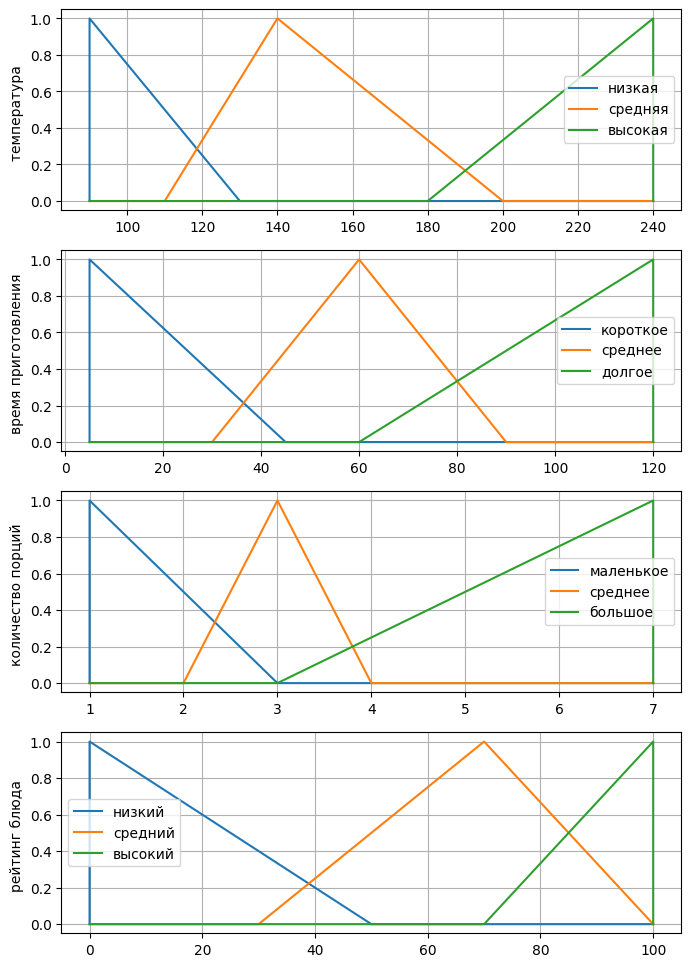

In [5]:
model.print_input_vars()

Результат фаззификации:
('температура ', ('средняя', 0.8333333333333334))
('время приготовления ', ('среднее', 1.0))
('количество порций ', ('маленькое', 1))

Агрегация и активация
Нашлись следующие правила
1: [температура средняя] AND [время приготовления среднее] AND [количество порций маленькое] THEN [рейтинг блюда средний](0.8333333333333334)
2: [температура средняя] AND [время приготовления среднее] THEN [рейтинг блюда средний](0.8333333333333334)
3: [количество порций маленькое] AND [время приготовления среднее] THEN [рейтинг блюда средний](1.0)
4: [температура средняя] AND [количество порций маленькое] THEN [рейтинг блюда низкий](0.8333333333333334)

Аккумуляция (объединяем следующие правила)
1: [температура средняя] AND [время приготовления среднее] AND [количество порций маленькое] THEN [рейтинг блюда средний](0.8333333333333334)
2: [температура средняя] AND [время приготовления среднее] THEN [рейтинг блюда средний](0.8333333333333334)
3: [количество порций маленькое] AND [вре

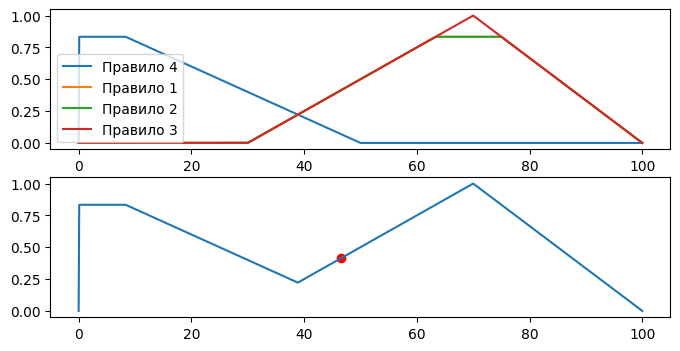

In [6]:
print(model.request(temp = 150, time = 60, portions = 1))